### [LO1, LO2, LO3, & LO4 – 45 Poin] Anda adalah seorang Data Scientist di bidang medis. Anda mendapatkan tugas untuk mengembangkan model Convolutional Neural Network (CNN) untuk melakukan klasifikasi gambar/citra

medis berikut ini sesuai dataset anda:
-  2A – Tumor otak
- 2B – Osteoarthritis
Download dataset yang telah disediakan dan buatlah model CNN untuk melakukan multiclass classification dengan perincian task berikut ini

### LINK GDRIVE : https://drive.google.com/drive/folders/1k3kojMGTkuhdRXKJLSQRCxM2kfWN-JXC?usp=sharing

##### a. [LO2 – 5 Poin] Lakukan Exploratory Data Analysis untuk memeriksa kondisi data yang anda miliki, seperti histogram warna untuk setiap kategori, aspect ratio, resolution, dan variability (lighting, angle, occlusions, dan sebagainya). Lalu pisahkan data anda menjadi train, validation, dan test dengan proporsi data validation sebesar 15% dari data train! Lakukan pre-processing pada data anda.

In [1]:
import os
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
import seaborn as sns
import pandas as pd
from collections import Counter
import random

# disini akan load dataset yang disediakan untuk kasus 2a
# membuat path untuk directory training dan testing
test_dir = "/kaggle/input/dataset2a/Testing"
train_dir = "/kaggle/input/dataset2a/Training"

# Ambil semua path gambar dan laod data tersebut
def load_image_paths(directory):
    data = []
    for label in os.listdir(directory):
        class_dir = os.path.join(directory, label)
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            data.append((img_path, label))
    return data

train_data = load_image_paths(train_dir)
test_data = load_image_paths(test_dir)

# mencoba menampilkan contoh data setelah di load 
print("Contoh data:", train_data[:3])

Contoh data: [('/kaggle/input/dataset2a/Training/pituitary/Tr-pi_0532.jpg', 'pituitary'), ('/kaggle/input/dataset2a/Training/pituitary/Tr-pi_0282.jpg', 'pituitary'), ('/kaggle/input/dataset2a/Training/pituitary/Tr-pi_1401.jpg', 'pituitary')]


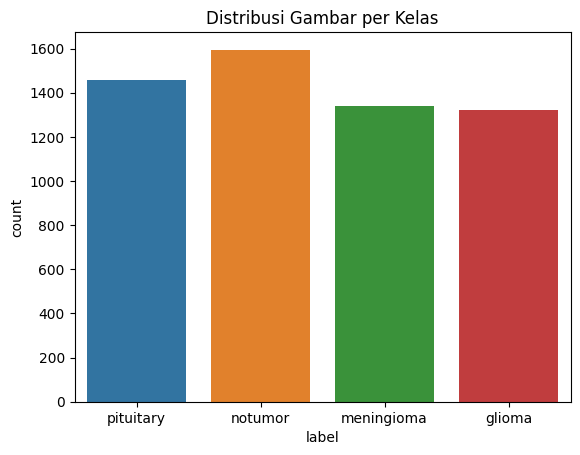

In [2]:
# membuat function untuk menghitung jumlah data per kelas
# setiap kelas akan dihitung dan menampilkan distribusinya 
def count_per_class(data):
    df = pd.DataFrame(data, columns=['path', 'label'])
    sns.countplot(x='label', data=df)
    plt.title("Distribusi Gambar per Kelas")
    plt.show()

count_per_class(train_data)


Kategori: pituitary


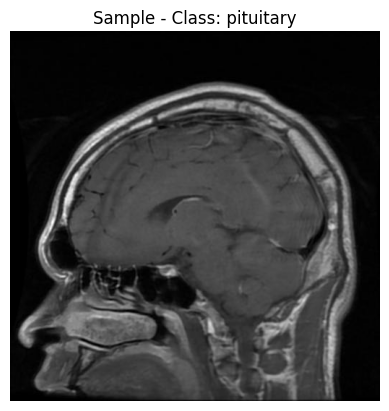

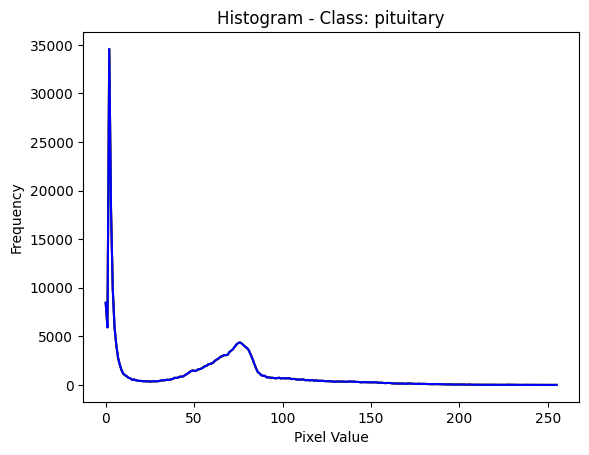

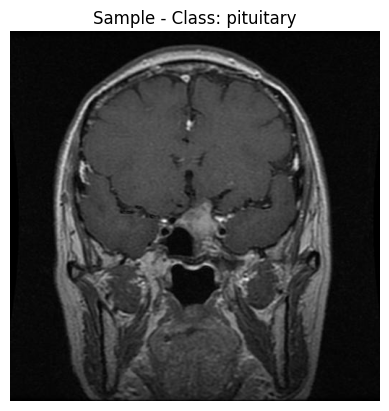

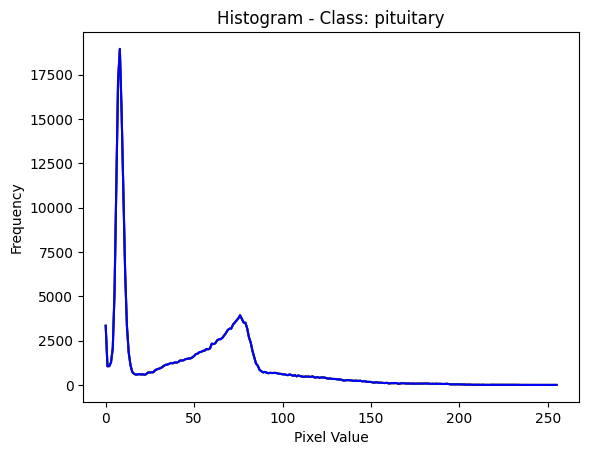

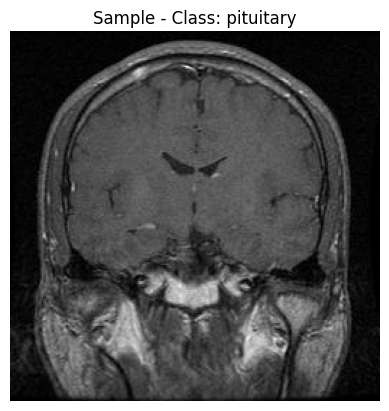

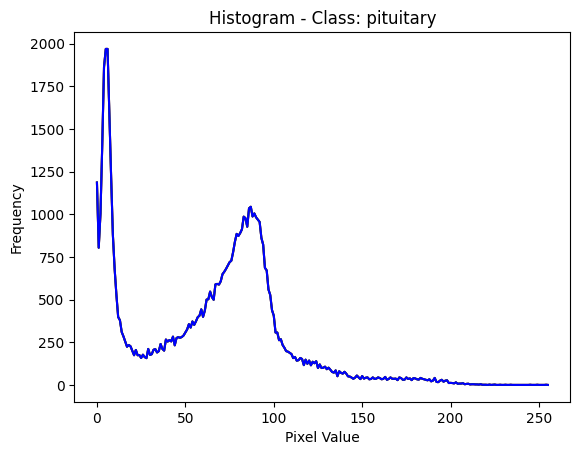

Kategori: notumor


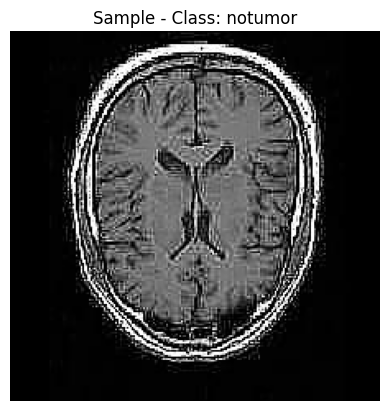

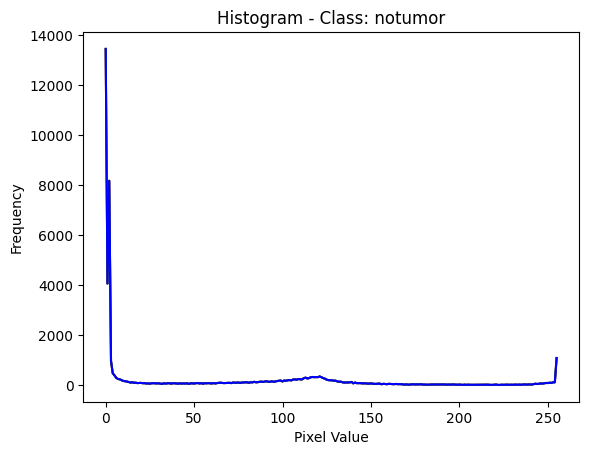

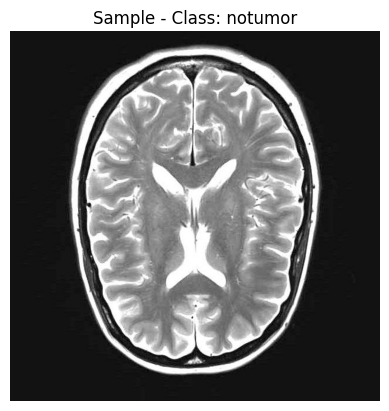

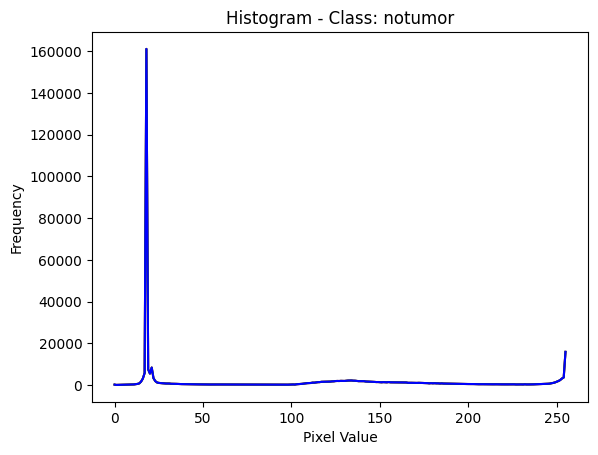

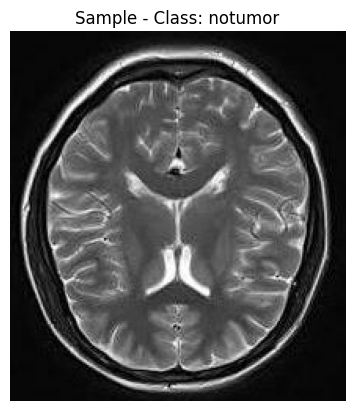

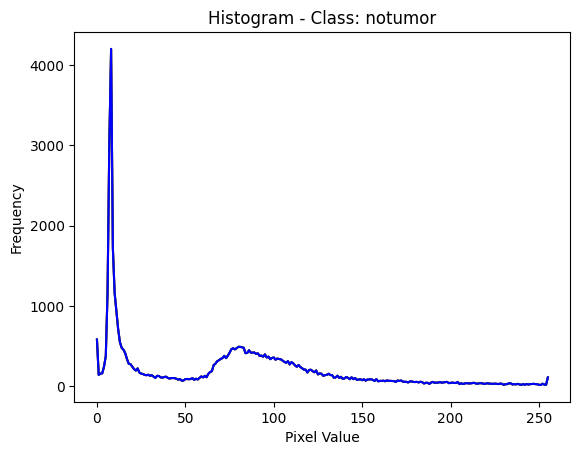

Kategori: meningioma


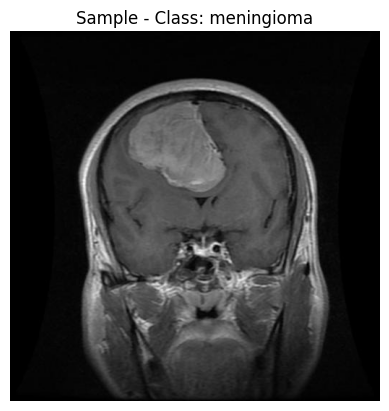

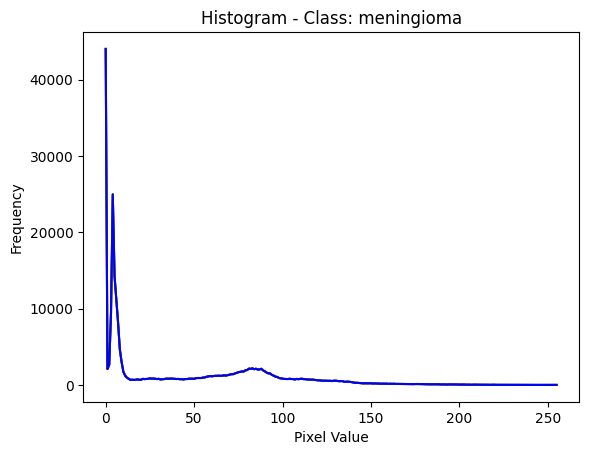

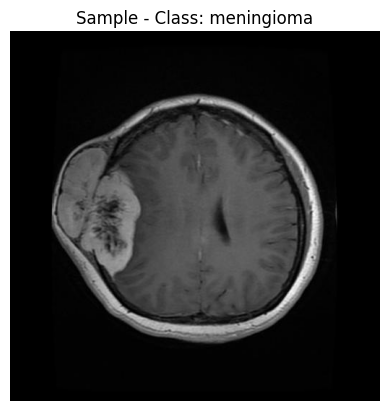

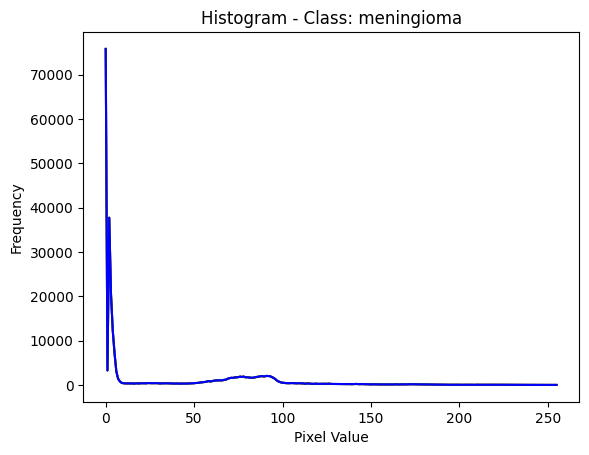

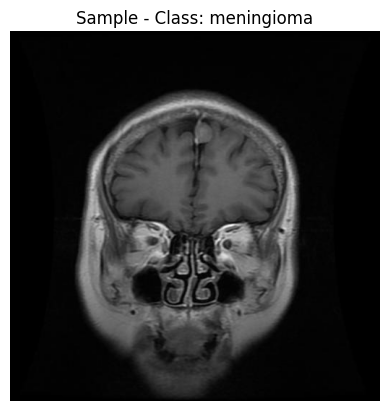

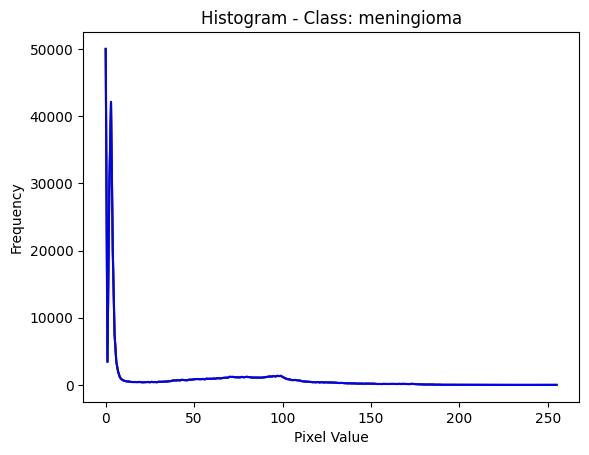

Kategori: glioma


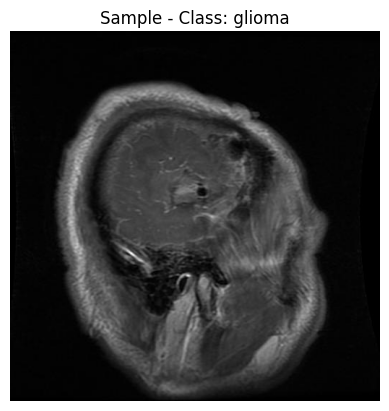

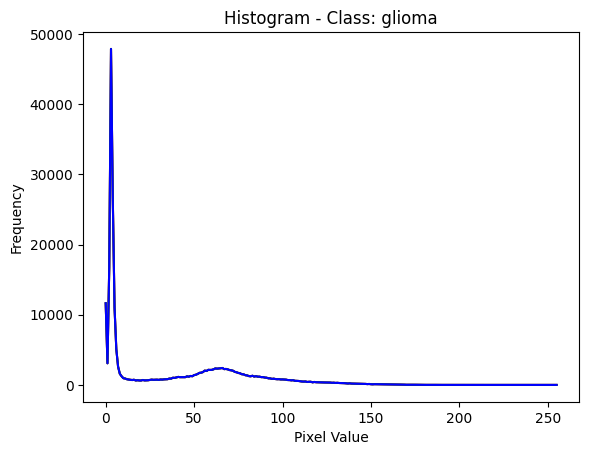

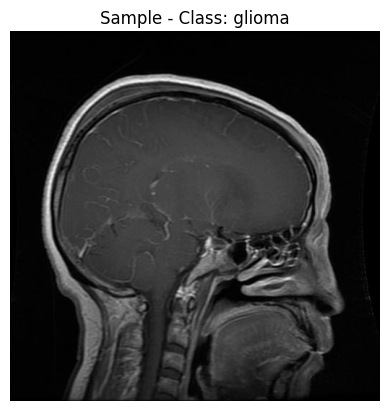

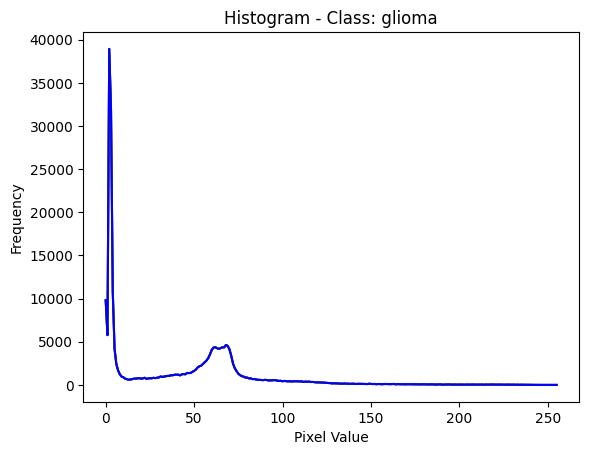

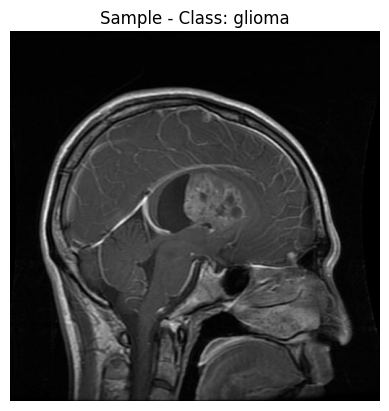

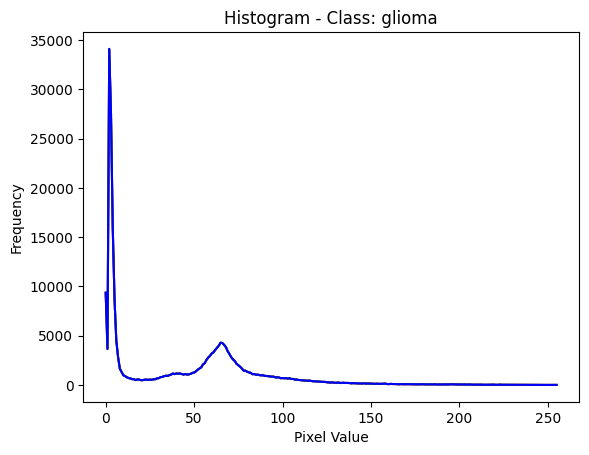

In [3]:
# Inisialisasi penyimpanan untuk aspect ratio dan resolusi
aspect_ratios = []
resolutions = []

# Ambil max 3 gambar per kategori
limit = 3

for label in os.listdir(train_dir):
    # mengambil gambar dari setiap kelas sejumlah limit
    print(f"Kategori: {label}")
    class_dir = os.path.join(train_dir, label)
    images = os.listdir(class_dir)[:limit]

    for file in images:
        # load gambar dari direktori setiap kelas
        img_path = os.path.join(class_dir, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # menampilkan gambar dari setiap kategori
        plt.imshow(img)
        plt.title(f"Sample - Class: {label}")
        plt.axis('off')
        plt.show()

        # membuat color histogram untuk gambar yang di plot
        colors = ("red", "green", "blue")
        for channel_id, color in enumerate(colors):
            histogram, bin_edges = np.histogram(
                img[:, :, channel_id], bins=256, range=(0, 256)
            )
            plt.plot(bin_edges[:-1], histogram, color=color)
        plt.title(f"Histogram - Class: {label}")
        plt.xlabel("Pixel Value")
        plt.ylabel("Frequency")
        plt.show()

#### setiap spektrum warna RGB (Red, Green, Blue) menunjukkan pola yang sama pada histogram, hal ini dapat disebabkan oleh warna pada gambar, yaitu hitam putih.

In [4]:
for label in os.listdir(train_dir):
    # semua data train akan di load dan dikalkulasikan untuk menghitung 
    # aspek rasio dan resolusi dari masing masing katergori
    print(f" Kategori: {label}")
    class_dir = os.path.join(train_dir, label)
    images = os.listdir(class_dir)

    for file in images:
        img_path = os.path.join(class_dir, file)
        img = cv2.imread(img_path)

        if img is None:
            continue
        
        h, w = img.shape[:2] #mengambil height dan weight dari gambar
        aspect_ratios.append(w / h) #menghitung rasio
        resolutions.append((w, h)) #menyimpan resolusi

 Kategori: pituitary
 Kategori: notumor
 Kategori: meningioma
 Kategori: glioma


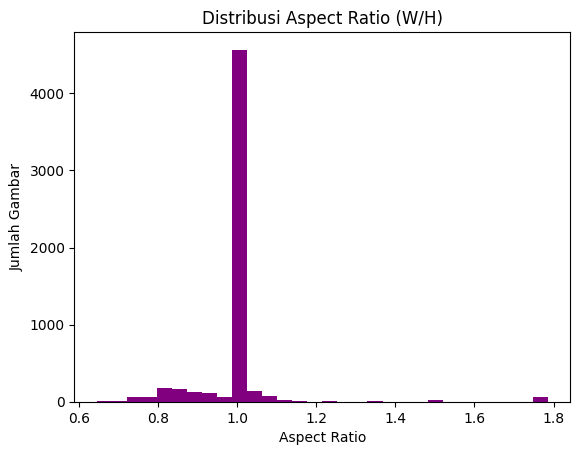

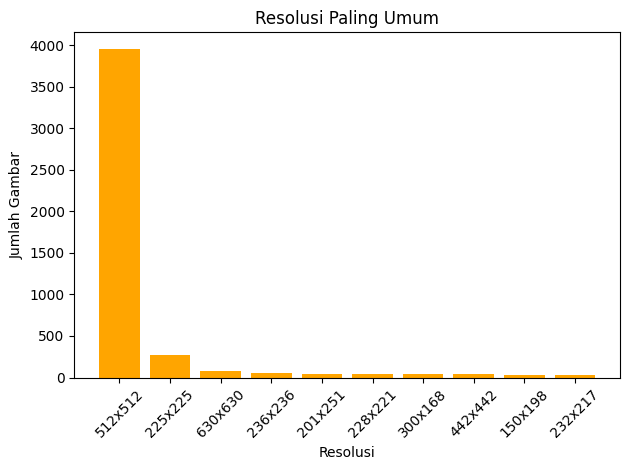

In [5]:
# menampilkan distribusi aspek ratio
plt.hist(aspect_ratios, bins=30, color='purple')
plt.title("Distribusi Aspect Ratio (W/H)")
plt.xlabel("Aspect Ratio")
plt.ylabel("Jumlah Gambar")
plt.show()

# menampilkan distribusi gambar yang paling umum
res_counts = Counter(resolutions)
most_common_res = dict(res_counts.most_common(10))

plt.bar([f"{w}x{h}" for (w, h) in most_common_res.keys()], most_common_res.values(), color='orange')
plt.title("Resolusi Paling Umum")
plt.xlabel("Resolusi")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### disini dapat dilihat bahwa beberapa data terdapat yang resolusinya tidak 512 x 512, dan juga ada yang aspek rationya tidak 1. oleh karena itu data image harus di resize dan normalisasi

 Variability Visual - Class: pituitary


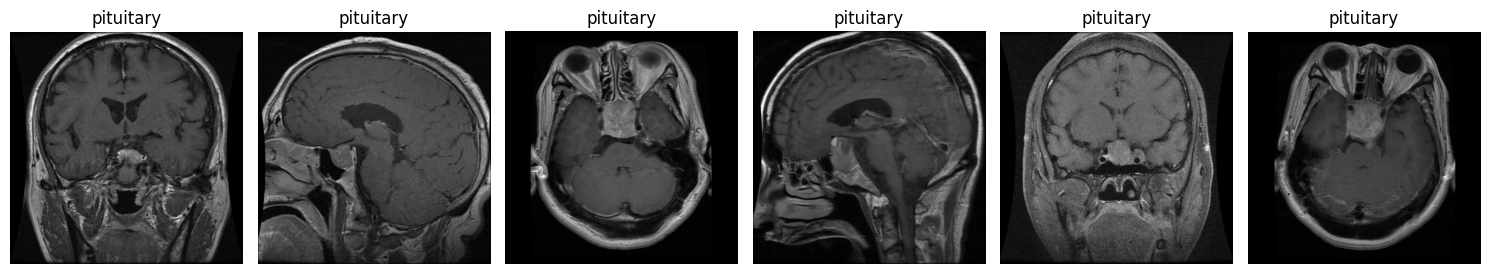

 Variability Visual - Class: notumor


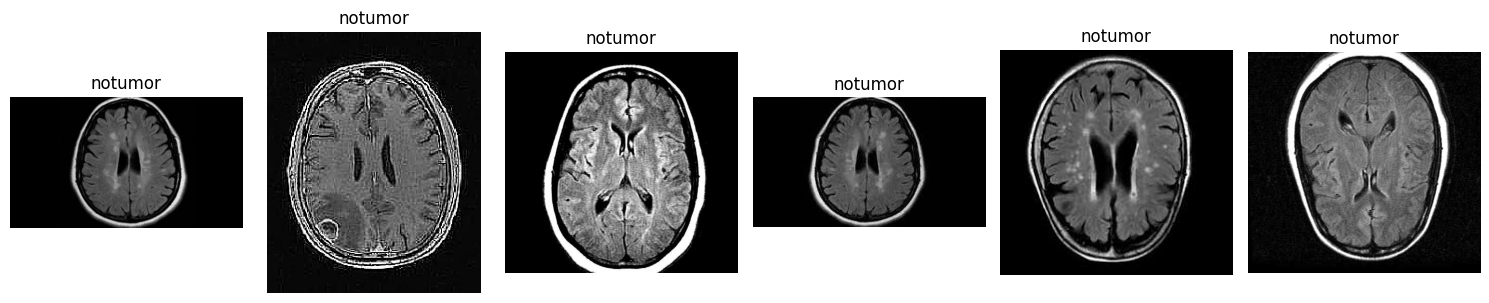

 Variability Visual - Class: meningioma


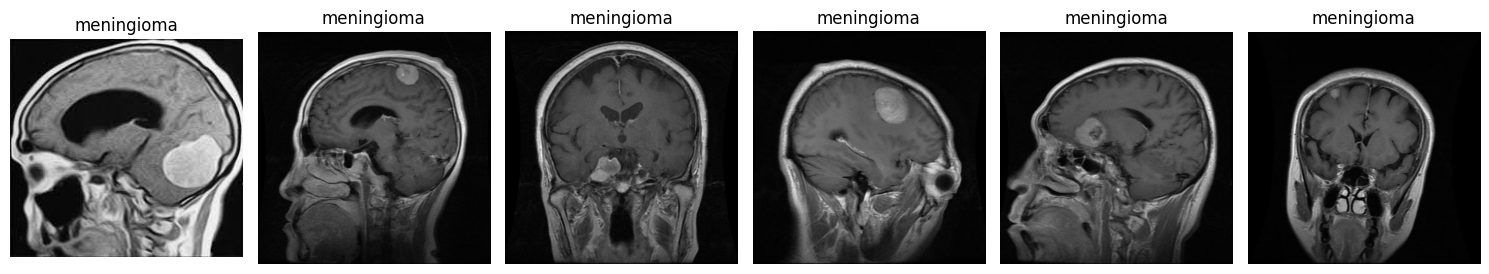

 Variability Visual - Class: glioma


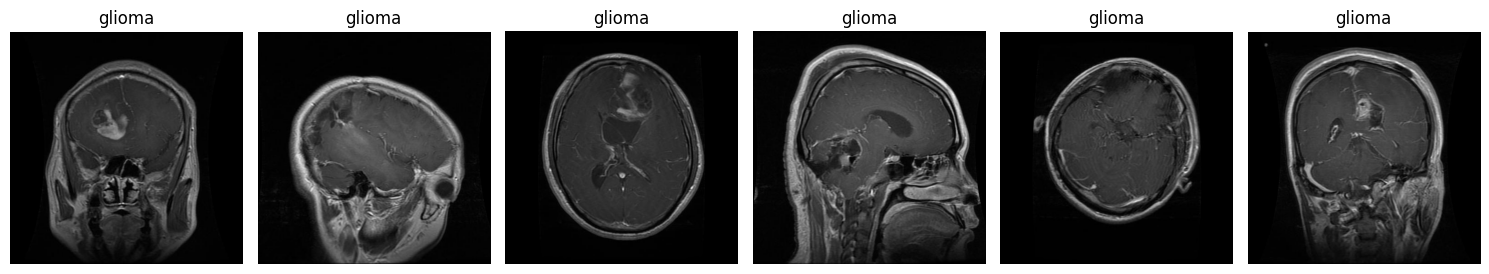

In [6]:
# menunjukkan bentuk data image yang dimiliki sejumlah gambar dari setiap kelas
num_samples = 6  # jumlah gambar per kelas

# mengumpulkan gambar-gambar dari setiap kelas dalam folder train_dir.
for label in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, label)
    image_list = os.listdir(class_dir)

    print(f" Variability Visual - Class: {label}")

    # membuat sub plot dan menampilkan gambar acak
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    sample_paths = random.sample(image_list, min(num_samples, len(image_list)))

    # membaca gambar -> mengonversi ke format RGB dan menampilkannya
    for i, file in enumerate(sample_paths):
        img_path = os.path.join(class_dir, file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(f"{label[:10]}")
    plt.tight_layout()
    plt.show()

#### kita dapat melihat bahwa data memiliki berbagai sudut pandang, ada yang diambil dari atas dan ada juga yang dari samping, dengan peletakan dan posisi yang berbeda. Semua gambar memiliki warna hitam putih, dan ukuran gambarnya juga tidak konsisten.

In [7]:
# mengecek jumlah data untuk di train dan test
print(len(train_data), "Train Image Data")
print(len(test_data), "Test Image Data")

5712 Train Image Data
1311 Test Image Data


In [8]:
# import libraries untuk data train dan untuk ambil file tertentu
from sklearn.model_selection import train_test_split
import glob

In [9]:
# menyimpan semua image berdasarkan path label
image_paths = []
labels = []

# untuk data yang ada dalam train akan di load dan di simpan kedalam image_paths dan labels
for class_name in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, class_name)
    if os.path.isdir(class_dir):
        for img_file in glob.glob(os.path.join(class_dir, '*')):
            image_paths.append(img_file)
            labels.append(class_name)

# untuk menyimpan data image untuk train 
test_paths = []
test_labels = []

# load data dan di simpan ke dalam list tersebut
for class_name in os.listdir(test_dir):
    class_dir = os.path.join(test_dir, class_name)
    if os.path.isdir(class_dir):
        for img_file in glob.glob(os.path.join(class_dir, '*')):
            test_paths.append(img_file)
            test_labels.append(class_name)

# split data train sebanyak 15% menjadi validation data
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.15, stratify=labels, random_state=42
)

# print informasi tentang data, ukuran test train valnya dan juga jumlah data per label
print(f"Total images: {len(image_paths)}")
print(f"Train images: {len(train_paths)}")
print(f"Validation images: {len(val_paths)}")
print(f"Test images: {len(test_paths)}")

print(f"Train labels: {Counter(train_labels)}")
print(f"Validation labels: {Counter(val_labels)}")
print(f"Test labels: {Counter(test_labels)}")

Total images: 5712
Train images: 4855
Validation images: 857
Test images: 1311
Train labels: Counter({'notumor': 1356, 'pituitary': 1238, 'meningioma': 1138, 'glioma': 1123})
Validation labels: Counter({'notumor': 239, 'pituitary': 219, 'meningioma': 201, 'glioma': 198})
Test labels: Counter({'notumor': 405, 'meningioma': 306, 'pituitary': 300, 'glioma': 300})


In [10]:
# preprocess data dengan menyamakan ukuran, dan juga conversi warna ke RGB
def preprocess_image(img_path, target_size=(224, 224)):
    img = cv2.imread(img_path)  # BGR format
    img = cv2.resize(img, target_size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    return img
    
# apply preprocessing function ke data dan membuat variable untuk modelling nantinya 
X_train = [preprocess_image(path) for path in train_paths]
X_val   = [preprocess_image(path) for path in val_paths]
X_test  = [preprocess_image(path) for path in test_paths]  
y_train = train_labels
y_val   = val_labels    
y_test  = test_labels

# konversi data dan label ke bentuk numpy array
X_train = np.array(X_train)
X_val   = np.array(X_val)
X_test  = np.array(X_test)
y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

# menampilkan dimensi (shape) dari dataset dan label untuk format yang benar 
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape) 
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4855, 224, 224, 3)
y_train shape: (4855,)
X_val shape: (857, 224, 224, 3)
y_val shape: (857,)
X_test shape: (1311, 224, 224, 3)
y_test shape: (1311,)


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation hanya untuk training
# dimana disini data akan di augmentasi, tujuannya adalah untuk mengurangi overfitting, dan juga membantu model agar dapat mempelajari pola yang lebih general.

train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalisasi
    rotation_range=20,           # Rotasi acak hingga 20 derajat
    width_shift_range=0.1,       # Pergeseran lebar
    height_shift_range=0.1,      # Pergeseran tinggi
    shear_range=0.1,             # Shear transform
    zoom_range=0.1,              # Zoom acak
    horizontal_flip=True,        # Flip horizontal acak
    fill_mode='nearest'          # Metode pengisian piksel kosong
)

# Validation dan test TIDAK pakai augmentasi
# karena validation dan test digunakan untuk menilai hasil trainingnya 
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255) 

2025-04-16 05:59:18.113381: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744783158.380362      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744783158.458228      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [12]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# untuk encode label, labelnya dari categorical string akan diubah menjadi numerik dengan label encoder kemudian akan di encode lagi dengan one hot encoder 
# One-hot encoding sangat penting untuk model seperti neural networks (Keras, TensorFlow) karena model tidak boleh menganggap label kategori memiliki urutan atau nilai numerik tertentu.
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

# membuat mapping antar kelas
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)

# mengubah label yang sudah di encode kedalam format OHE
OHE = OneHotEncoder(sparse_output=False)
y_train_onehot = OHE.fit_transform(y_train_encoded.reshape(-1, 1))
y_val_onehot = OHE.transform(y_val_encoded.reshape(-1, 1))
y_test_onehot = OHE.transform(y_test_encoded.reshape(-1, 1))

Label mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [13]:
# membuat generator untuk setiap data yang dimiliki 
train_generator = train_datagen.flow(
    X_train, y_train_onehot,
    batch_size=32,
    shuffle=True
)

val_generator = val_datagen.flow(
    X_val, y_val_onehot,
    batch_size=32,
    shuffle=False
)

test_generator = test_datagen.flow(
    X_test, y_test_onehot,
    batch_size=32,
    shuffle=False
)

# tujuan -> untuk menghasilkan batch data dan label yang siap digunakan untuk pelatihan,
# validasi, dan pengujian model.

### b. [LO2, LO3, & LO4 – 10 Poin] Buatlah sebuah model CNN dengan arsitektur AlexNet secara manual (tidak menggunakan pre-trained model dari Keras) seperti pada gambar di samping dan adaptasikan output layer pada gambar sesuai dengan dataset anda. Model ini akan disebut sebagai Baseline Model. Lakukan training pada model anda dengan minimal 10 epoch.

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation

# menyesuaikan dengan arsitektur AlexNet ini merupakan code untuk baseline model yang dibuat dan diadaptasikan output layernya sesuai dengna dataset.
model_baseline = Sequential([
    # 96: jml kernel, (11,11): ukuran kernel, strides=4 : pergeseran kernel, (224,224,3): 224x224 pixel dgn 3 channel RGB
    Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(pool_size=(3,3), strides=2),

    Conv2D(256, (5,5), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    Conv2D(384, (3,3), padding='same', activation='relu'),
    Conv2D(384, (3,3), padding='same', activation='relu'),
    Conv2D(256, (3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])
# keseluruhan struktur mengikuti dengan soal, perbedaan hanya terdapat di output yang menyesuaikan dengan jumlah kelas yang akan jadi output,
# maka diganti dari 1000 menjadi 4 

# mmenyiapkan model dgn menggunakan adam algorithm, menggunakan loss function untuk klasifikasi kelas dan mengukur akurasi slama training and eval
model_baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_baseline.summary() #summarize

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-04-16 06:00:17.827707: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 54, 54, 96)          │          34,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 26, 26, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 26, 26, 256)         │         614,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 384)         │         885,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 12, 12, 384)         │       1,327,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 256)         │         884,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4096)                │      26,218,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │          16,388 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 46,763,396 (178.39 MB)

 Trainable params: 46,763,396 (178.39 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# kemudian model di train dengan 10 epoch 
history_model_baseline = model_baseline.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    validation_steps=len(val_generator)
)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


152/152 ━━━━━━━━━━━━━━━━━━━━ 391s 3s/step - accuracy: 0.3040 - loss: 1.6882 - val_accuracy: 0.5578 - val_loss: 1.0339
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 418s 2s/step - accuracy: 0.6101 - loss: 0.9412
Epoch 3/10


/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


152/152 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.7282 - loss: 0.6963 - val_accuracy: 0.7690 - val_loss: 0.5879
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.7572 - loss: 0.6161
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.7717 - loss: 0.5967 - val_accuracy: 0.7970 - val_loss: 0.5091
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.7819 - loss: 0.5654
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.8145 - loss: 0.5093
Epoch 9/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.8160 - loss: 0.4872 - val_accuracy: 0.8483 - val_loss: 0.4008
Epoch 10/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.8121 - loss: 0.4831


##### c. [LO2, LO3, & LO4 – 15 Poin] Modifikasi arsitektur AlexNet yang sudah dibuat. Anda bisa menambahkan DropOut, Batch Normalization, dan sebagainya. Anda juga bisa mengganti modelnya dengan arsitektur CNN lain seperti DenseNet, EfficientNet, dan sebagainya. Jelaskan alasan modifikasi anda dan lakukan training (minimal 10 epoch) serta fine-tuning untuk hyperparameter pada model ini.

In [17]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# ini merupakan model yang di modifikasi dari AlexNet, dengan menambahkan batch normalization, dropout, dan mengubah neuronnya tujuannya adalah mencegah overfitting.
model_mod = Sequential([
    # Layer 1
    Conv2D(64, (11, 11), strides=4, activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    # Layer 2
    Conv2D(128, (5, 5), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    # Layer 3, 4, 5
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    # Fully Connected Layers
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')  # Ganti 4 sesuai jumlah kelas
])

# Compile model
model_mod.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Summary
model_mod.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 54, 54, 64)          │          23,296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 54, 54, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 26, 26, 128)         │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 26, 26, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 12, 12, 128)         │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 3200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 512)                 │       1,638,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,180,548 (12.13 MB)

 Trainable params: 3,180,164 (12.13 MB)

 Non-trainable params: 384 (1.50 KB)

In [18]:
# kemudian train modified model
history_model_mod = model_mod.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    validation_steps=len(val_generator)
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.4330 - loss: 1.3131 - val_accuracy: 0.2567 - val_loss: 1.5443
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 149s 960ms/step - accuracy: 0.6696 - loss: 0.8291
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.7233 - loss: 0.6865 - val_accuracy: 0.7456 - val_loss: 0.6667
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 150s 964ms/step - accuracy: 0.7623 - loss: 0.6129
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.7932 - loss: 0.5385 - val_accuracy: 0.6989 - val_loss: 0.8006
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 196s 1000ms/step - accuracy: 0.8149 - loss: 0.4754
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.8378 - loss: 0.4246 - val_accuracy: 0.6184 - val_loss: 0.8990
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 148s 956ms/step - accuracy: 0.8646 - loss: 0.3746
Epoch 9/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.8563 - loss: 0.3964 - val_accuracy: 0.8705 - val_loss: 0

##### d. [LO2, LO3, & LO4 – 10 Poin] Lakukan evaluasi performa model anda pada data test dengan menggunakan minimal 3 evaluation metrics. Analisis, jelaskan, dan simpulkan hasilnya.

In [19]:
# disini akan melakukan evaluasi dari test 
test_loss, test_accuracy = model_baseline.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# akurasi dan loss yang di dapatkan dari data ini, hasilnya baik di 0.79 atau 79% berarti model dapat menemukan pola dari images yang kita miliki.

41/41 ━━━━━━━━━━━━━━━━━━━━ 22s 539ms/step - accuracy: 0.8606 - loss: 0.3919
Test Loss: 0.5288
Test Accuracy: 0.7986


41/41 ━━━━━━━━━━━━━━━━━━━━ 23s 551ms/step
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       300
           1       0.72      0.44      0.54       306
           2       0.80      0.98      0.88       405
           3       0.90      0.89      0.90       300

    accuracy                           0.80      1311
   macro avg       0.79      0.78      0.78      1311
weighted avg       0.79      0.80      0.78      1311



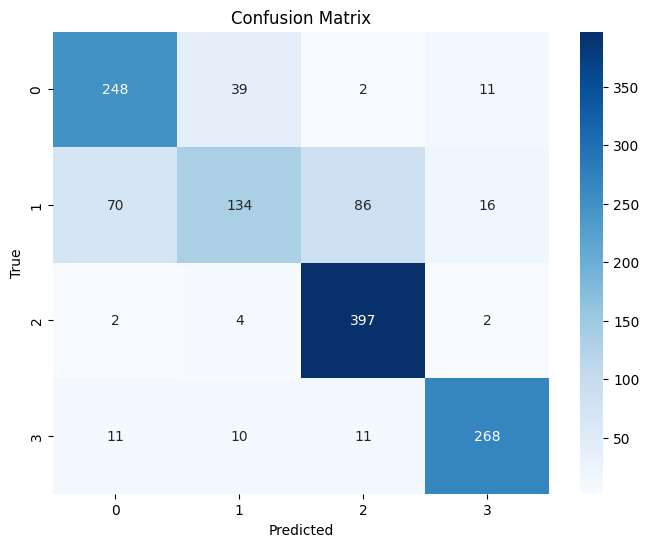

In [20]:
y_true_classes = np.argmax(y_test_onehot, axis=1)

# Predictions dari model
y_pred_probs = model_baseline.predict(test_generator)  # or model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# evaluasi
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_true_classes, y_pred_classes))

# membuat Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


#### dapat dilihat bahwa model dapat menebak class dengan cukup baik disini dengan menyesuaikan hasil class dari label encoder diatas, maka model sudah cukup baik

In [21]:
# untuk modified model, dapat dilihat bahwa terdapat peningkatan dari model baseline dengan accuracy 80% 
test_loss, test_accuracy = model_mod.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 227ms/step - accuracy: 0.9471 - loss: 0.1622
Test Loss: 0.3421
Test Accuracy: 0.8818


41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       300
           1       0.82      0.72      0.77       306
           2       0.89      0.98      0.93       405
           3       0.88      0.99      0.93       300

    accuracy                           0.88      1311
   macro avg       0.88      0.87      0.87      1311
weighted avg       0.88      0.88      0.88      1311



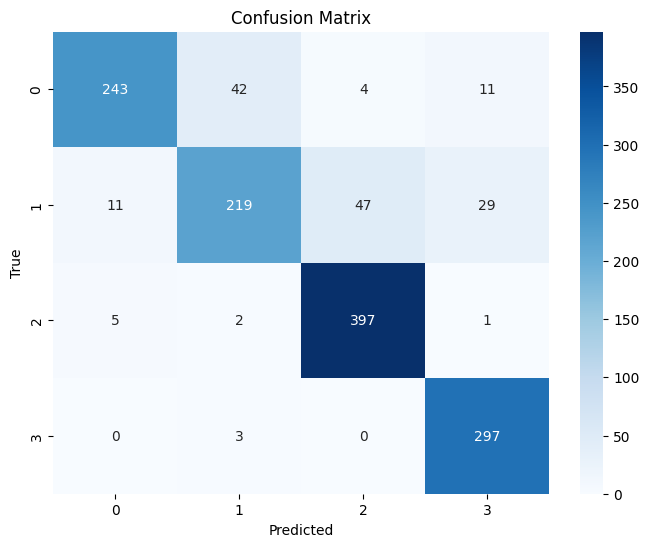

In [22]:
y_true_classes = np.argmax(y_test_onehot, axis=1) #mengubah label OHE menjadi label kelas yg sesuai

y_pred_probs = model_mod.predict(test_generator)  # or model.predict(X_test), memprediksi probabilitas kls
y_pred_classes = np.argmax(y_pred_probs, axis=1) #mengubah probability kelas menjadi label kelas yg diprediksi mdoel

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_true_classes, y_pred_classes))

# menampilkan Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


#### model yang merupakan modifikasi dari baseline model, dapat dilihat acc dan evaluasi lainnya memiliki pengingkatan, dari baseline model, dengan begitu dapat dikatakan dengan menambah batchnormalization dan dropout menjadi salah satu cara untuk menaikan performa

##### e. [LO1, LO2 – 5 Points] Buatlah video presentasi yang menjelaskan langkah-langkah pengerjaan anda serta hasil analisis anda dengan durasi maksimal 15 menit.